In [6]:
#LOADING THE DATASET


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("Zomato data .csv")

df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [7]:
# Checking shape, columns, data types, missing values, and duplicate records

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())


Shape: (148, 7)

Columns:
['name', 'online_order', 'book_table', 'rate', 'votes', 'approx_cost(for two people)', 'listed_in(type)']

Data Types:
name                             str
online_order                     str
book_table                       str
rate                             str
votes                          int64
approx_cost(for two people)    int64
listed_in(type)                  str
dtype: object

Missing Values:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Duplicate Records:
0


In [8]:
# Generate descriptive statistics for the numerical columns.

df.describe()


,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [9]:
# Handle missing values and duplicate records

print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("\nDuplicate records after cleaning:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)


Missing values before cleaning:
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Duplicate records after cleaning: 0
Shape after removing duplicates: (148, 7)


In [10]:
#  Clean and convert the rate column

df["rate"] = (
    df["rate"]
    .astype(str)
    .str.replace("/5", "", regex=False)
    .str.strip()
)

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print(df["rate"].head())
print("\nData type:", df["rate"].dtype)


0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64

Data type: float64


In [11]:
# Clean and convert approx_cost(for two people)

df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

print(df["approx_cost(for two people)"].head())
print("\nData type:", df["approx_cost(for two people)"].dtype)


0    800
1    800
2    800
3    300
4    600
Name: approx_cost(for two people), dtype: int64

Data type: int64


In [12]:
# Identify and handle invalid or inconsistent values

print("Invalid ratings:")
print(df[(df["rate"] < 0) | (df["rate"] > 5)])

print("\nInvalid votes:")
print(df[df["votes"] < 0])

print("\nInvalid costs:")
print(df[df["approx_cost(for two people)"] <= 0])

# Replace invalid values with NaN
df.loc[(df["rate"] < 0) | (df["rate"] > 5), "rate"] = np.nan
df.loc[df["votes"] < 0, "votes"] = np.nan
df.loc[df["approx_cost(for two people)"] <= 0, "approx_cost(for two people)"] = np.nan

# Fill numerical missing values with median
df["rate"] = df["rate"].fillna(df["rate"].median())
df["votes"] = df["votes"].fillna(df["votes"].median())
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].fillna(
    df["approx_cost(for two people)"].median()
)

print("\nMissing numerical values after cleaning:")
print(df[["rate", "votes", "approx_cost(for two people)"]].isnull().sum())


Invalid ratings:
Empty DataFrame
Columns: [name, online_order, book_table, rate, votes, approx_cost(for two people), listed_in(type)]
Index: []

Invalid votes:
Empty DataFrame
Columns: [name, online_order, book_table, rate, votes, approx_cost(for two people), listed_in(type)]
Index: []

Invalid costs:
Empty DataFrame
Columns: [name, online_order, book_table, rate, votes, approx_cost(for two people), listed_in(type)]
Index: []

Missing numerical values after cleaning:
rate                           0
votes                          0
approx_cost(for two people)    0
dtype: int64


In [13]:
# Clean customer review text

review_columns = [col for col in df.columns if "review" in col.lower()]

if review_columns:
    review_col = review_columns[0]
    df[review_col] = (
        df[review_col]
        .astype(str)
        .str.replace(r"[^A-Za-z0-9\s]", "", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    print(f"Cleaned review column: {review_col}")
else:
    print("No customer review-text column was found in this CSV.")
    print("Review-text cleaning is skipped for this dataset.")


No customer review-text column was found in this CSV.
Review-text cleaning is skipped for this dataset.


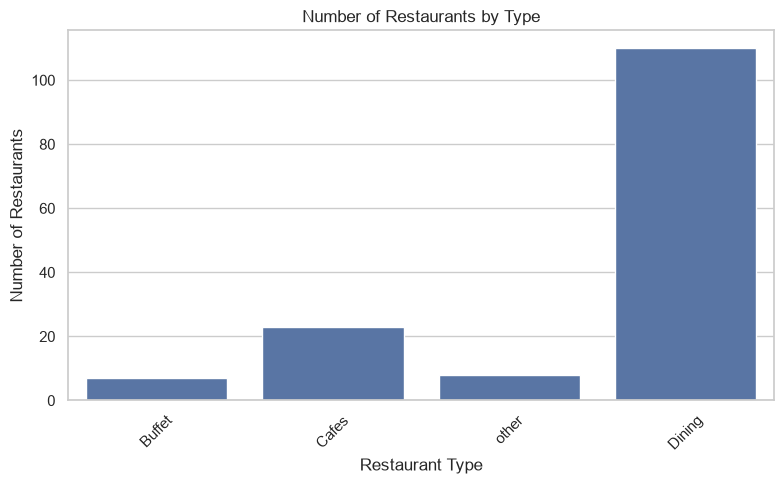

In [14]:
# Count plot – Number of restaurants in each restaurant type

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="listed_in(type)")
plt.title("Number of Restaurants by Type")
plt.xlabel("Restaurant Type")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


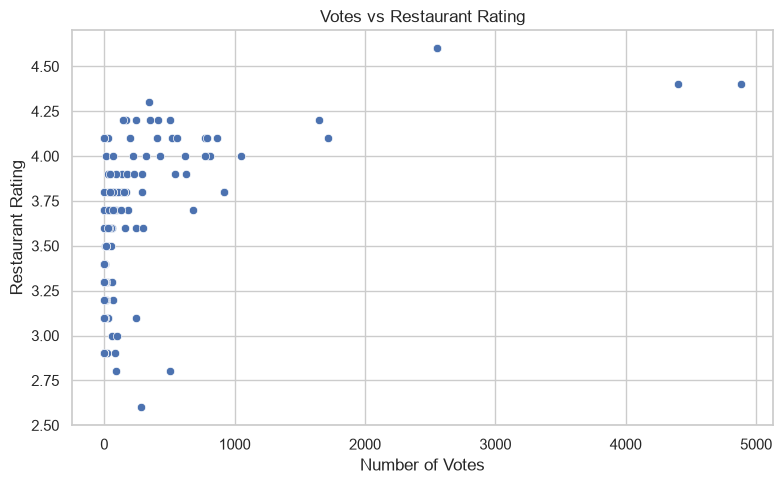

Correlation between votes and rating: 0.48984428790988793


In [15]:
#  Scatter plot – Relationship between votes and restaurant ratings

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="votes", y="rate")
plt.title("Votes vs Restaurant Rating")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Rating")
plt.tight_layout()
plt.show()

print("Correlation between votes and rating:",
      df["votes"].corr(df["rate"]))


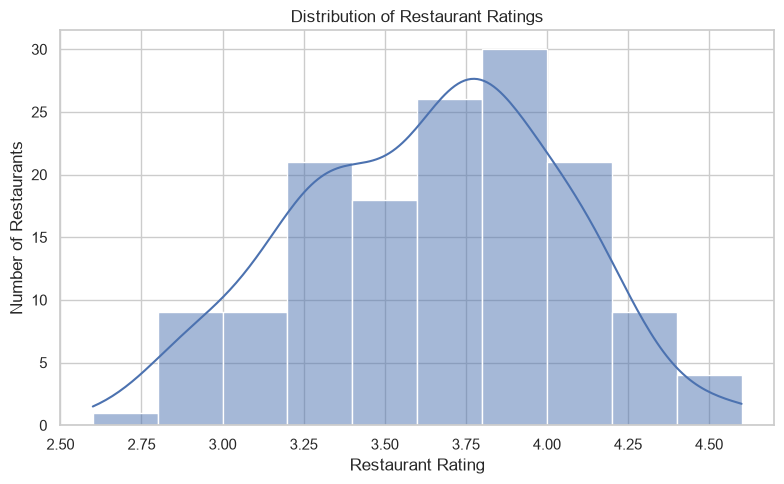

In [16]:
# Histogram – Distribution of restaurant ratings

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="rate", bins=10, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Restaurants")
plt.tight_layout()
plt.show()


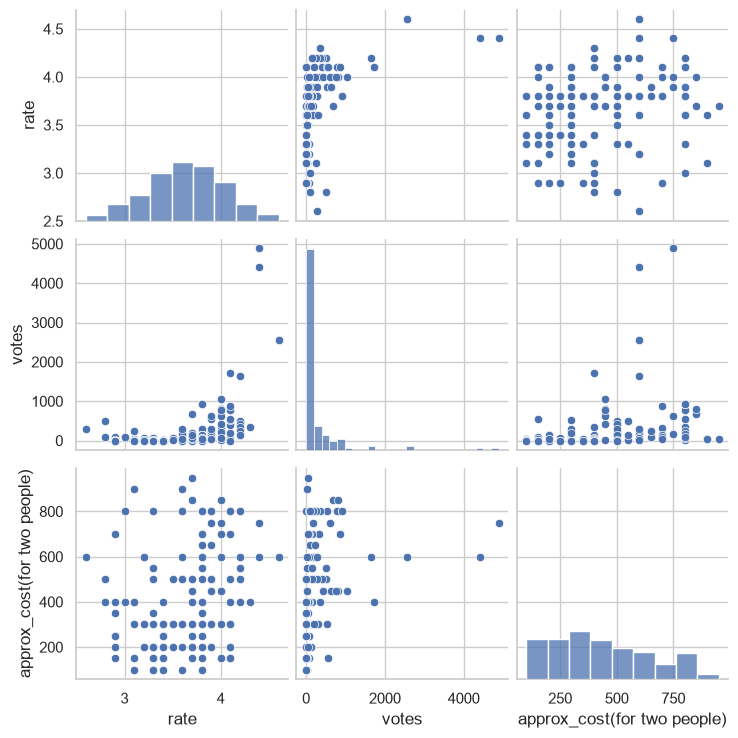

In [17]:
#Pair plot – Rating, votes, and approximate cost

sns.pairplot(
    df[["rate", "votes", "approx_cost(for two people)"]],
    diag_kind="hist"
)
plt.show()


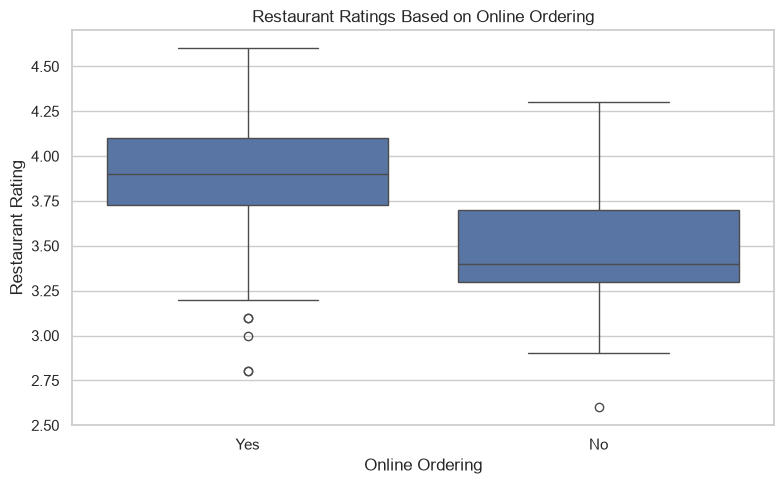

Average rating by online ordering:
online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64


In [18]:
#Box plot – Restaurant ratings based on online ordering availability

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="online_order", y="rate")
plt.title("Restaurant Ratings Based on Online Ordering")
plt.xlabel("Online Ordering")
plt.ylabel("Restaurant Rating")
plt.tight_layout()
plt.show()

print("Average rating by online ordering:")
print(df.groupby("online_order")["rate"].mean())


In [19]:
# Most common words used in customer reviews

if "reviews_list" in df.columns:
    from collections import Counter
    import re

    text = " ".join(df["reviews_list"].dropna().astype(str))
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())
    print(Counter(words).most_common(20))
else:
    print("Skipped: 'reviews_list' column is not available.")


Skipped: 'reviews_list' column is not available.


In [20]:
#Positive or negative customer reviews

if "reviews_list" in df.columns:
    import nltk
    from nltk.sentiment import SentimentIntensityAnalyzer

    nltk.download("vader_lexicon")
    sia = SentimentIntensityAnalyzer()

    df["sentiment_score"] = df["reviews_list"].fillna("").apply(
        lambda x: sia.polarity_scores(str(x))["compound"]
    )

    df["sentiment"] = df["sentiment_score"].apply(
        lambda x: "Positive" if x > 0.05
        else ("Negative" if x < -0.05 else "Neutral")
    )

    print(df["sentiment"].value_counts())
else:
    print("Skipped: 'reviews_list' column is not available.")


Skipped: 'reviews_list' column is not available.


In [21]:
#Relationship between customer reviews and restaurant ratings

if "sentiment" in df.columns:
    print(df.groupby("sentiment")["rate"].mean())

    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="sentiment", y="rate")
    plt.title("Restaurant Ratings by Review Sentiment")
    plt.xlabel("Review Sentiment")
    plt.ylabel("Restaurant Rating")
    plt.tight_layout()
    plt.show()
else:
    print("Skipped: review sentiment is not available.")


Skipped: review sentiment is not available.
